# **Diabetes Prediction Using Machine Learning**


# **Project Outline**
1. Data Collection
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Selection
5. Model Building
6. Model Optimization
7. Model Evaluation
8. Business Insights & Recommendations

This dataset contained categorical data, and it was used to predict whether a person has diabetes or not using machine learning models.

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,ConfusionMatrixDisplay, roc_auc_score,roc_curve)
import warnings
warnings.filterwarnings("ignore")

# Data Loading and Exploration

In [ ]:
df = pd.read_csv("diabetes_dataset.csv")

In [ ]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [ ]:
df.tail()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
99995,46,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,...,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0
99996,41,Female,White,Graduate,Middle,Employed,Never,3,76,8.8,...,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0
99997,57,Female,Black,No formal,Upper-Middle,Employed,Former,4,121,9.9,...,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0
99998,47,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52,5.9,...,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0
99999,52,Female,White,Postgraduate,Middle,Employed,Never,1,248,2.7,...,31,183,87,91,142,15.93,5.73,27.9,Pre-Diabetes,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [ ]:
df.shape

(100000, 31)

In [ ]:
df.sample(5)

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
74780,31,Female,White,Graduate,Upper-Middle,Employed,Never,1,208,7.2,...,65,60,156,95,173,2.59,6.50,15.8,Type 2,1
31274,87,Male,Asian,Graduate,Lower-Middle,Employed,Former,5,67,3.0,...,64,50,162,123,174,5.47,7.33,39.5,Type 2,1
34237,26,Other,White,Highschool,Middle,Employed,Never,1,147,5.2,...,53,110,104,105,127,10.68,5.52,18.9,Pre-Diabetes,0
39859,52,Other,Black,Graduate,Upper-Middle,Employed,Never,1,15,6.1,...,52,122,136,102,139,7.68,6.07,29.4,Pre-Diabetes,0
83718,65,Female,White,Highschool,Middle,Employed,Former,4,21,4.6,...,56,55,138,125,170,10.96,6.51,37.5,Type 2,1


# Data Preprocessing

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
ethnicity,0
education_level,0
income_level,0
employment_status,0
smoking_status,0
alcohol_consumption_per_week,0
physical_activity_minutes_per_week,0
diet_score,0


As we can see there is no missing values

In [ ]:
df.duplicated().sum()

np.int64(0)

The dataset also doesn't have any duplicate values



In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

In [ ]:
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

Here I have converted the text columns into numbers so that machine learning models can use them

Outliers before treatment:
Column 'age': 0 outliers
Column 'alcohol_consumption_per_week': 458 outliers
Column 'physical_activity_minutes_per_week': 3199 outliers
Column 'diet_score': 337 outliers
Column 'sleep_hours_per_day': 900 outliers
Column 'screen_time_hours_per_day': 305 outliers
Column 'bmi': 744 outliers
Column 'waist_to_hip_ratio': 273 outliers
Column 'systolic_bp': 530 outliers
Column 'diastolic_bp': 731 outliers
Column 'heart_rate': 855 outliers
Column 'cholesterol_total': 309 outliers
Column 'hdl_cholesterol': 565 outliers
Column 'ldl_cholesterol': 349 outliers
Column 'triglycerides': 301 outliers
Column 'glucose_fasting': 745 outliers
Column 'glucose_postprandial': 634 outliers
Column 'insulin_level': 326 outliers
Column 'hba1c': 618 outliers
Column 'diabetes_risk_score': 914 outliers

Treating outliers...

Outliers after treatment (should be 0 or very close to 0 if capped):
Column 'age': 0 outliers
Column 'alcohol_consumption_per_week': 0 outliers
Column 'physical_activ

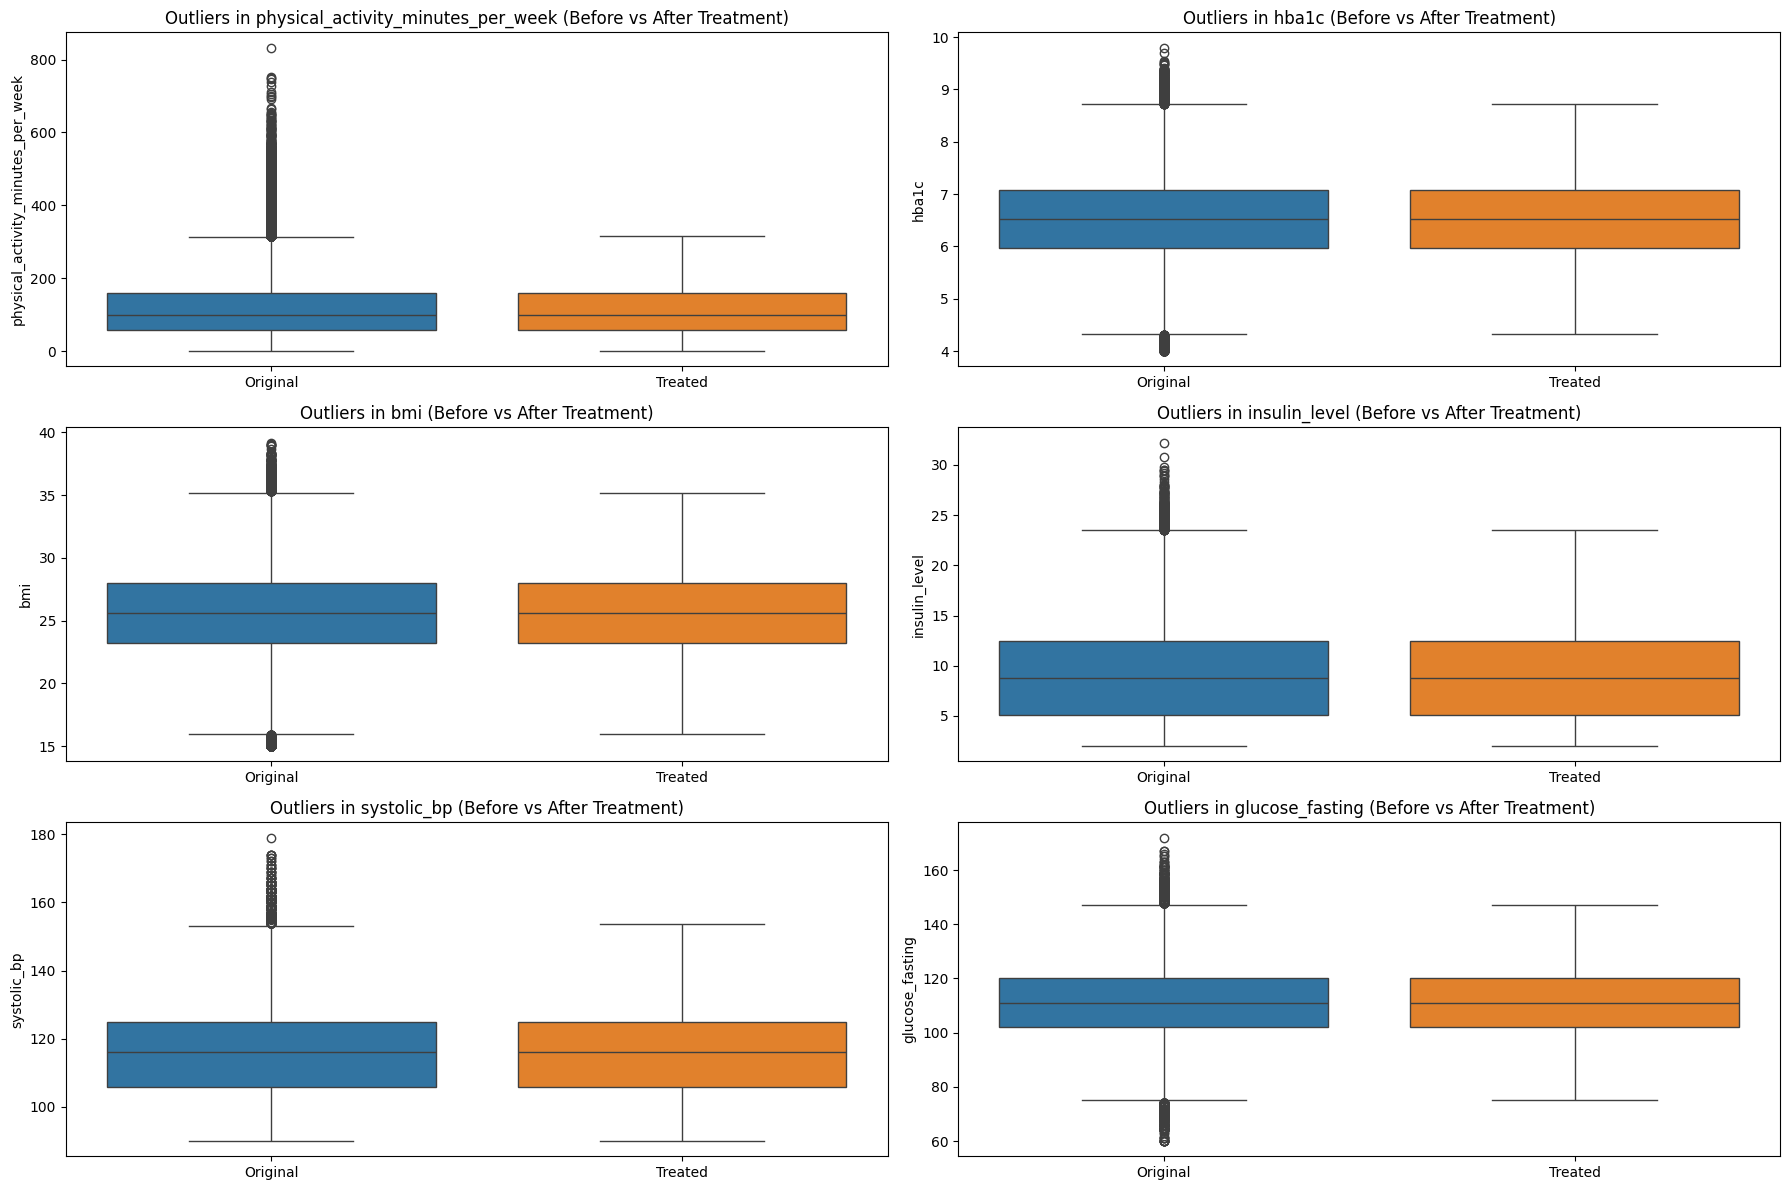

In [ ]:
df_treated = df.copy()

def treat_outliers_iqr(df_col):
    Q1 = df_col.quantile(0.25)
    Q3 = df_col.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_before = df_col[(df_col < lower_bound) | (df_col > upper_bound)]
    df_col_treated = df_col.clip(lower=lower_bound, upper=upper_bound)
    outliers_after = df_col_treated[(df_col_treated < lower_bound) | (df_col_treated > upper_bound)]

    return df_col_treated, len(outliers_before), len(outliers_after)

categorical_like_cols = [
    'gender', 'ethnicity', 'education_level', 'income_level', 'employment_status',
    'smoking_status', 'family_history_diabetes', 'hypertension_history',
    'cardiovascular_history', 'diabetes_stage', 'diagnosed_diabetes']
continuous_numerical_cols = [col for col in df.select_dtypes(include=np.number).columns if col not in categorical_like_cols]

outlier_counts_before = {}
outlier_counts_after = {}

print("Outliers before treatment:")
for col in continuous_numerical_cols:
    if col in df_treated.columns:
        df_treated[col], num_outliers_before, num_outliers_after = treat_outliers_iqr(df_treated[col])
        outlier_counts_before[col] = num_outliers_before
        outlier_counts_after[col] = num_outliers_after
        print(f"Column '{col}': {num_outliers_before} outliers")

print("\nTreating outliers...")

print("\nOutliers after treatment (should be 0 or very close to 0 if capped):")
for col in continuous_numerical_cols:
    if col in outlier_counts_after:
        print(f"Column '{col}': {outlier_counts_after[col]} outliers")


selected_cols_for_viz = [
    'physical_activity_minutes_per_week', 'hba1c', 'bmi', 'insulin_level',
    'systolic_bp', 'glucose_fasting']

plt.figure(figsize=(18, 12))

for i, col in enumerate(selected_cols_for_viz):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(data=pd.DataFrame({'Original': df[col], 'Treated': df_treated[col]}))
    plt.title(f'Outliers in {col} (Before vs After Treatment)')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

# Exploratory Data Analysis (EDA)

In [ ]:
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,1,0,1,2,0,2,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,4,1
1,48,0,4,1,3,0,1,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,1,0
2,60,1,2,1,3,3,2,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,4,1
3,74,0,1,1,1,1,2,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,4,1
4,46,1,4,0,3,1,2,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,4,1


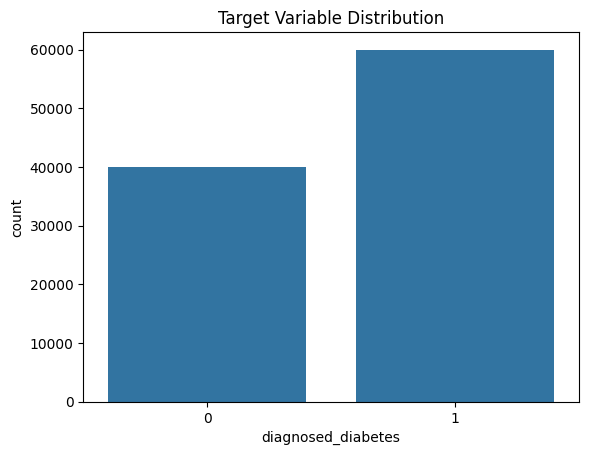

In [ ]:
sns.countplot(x=df['diagnosed_diabetes'])
plt.title("Target Variable Distribution")
plt.show()

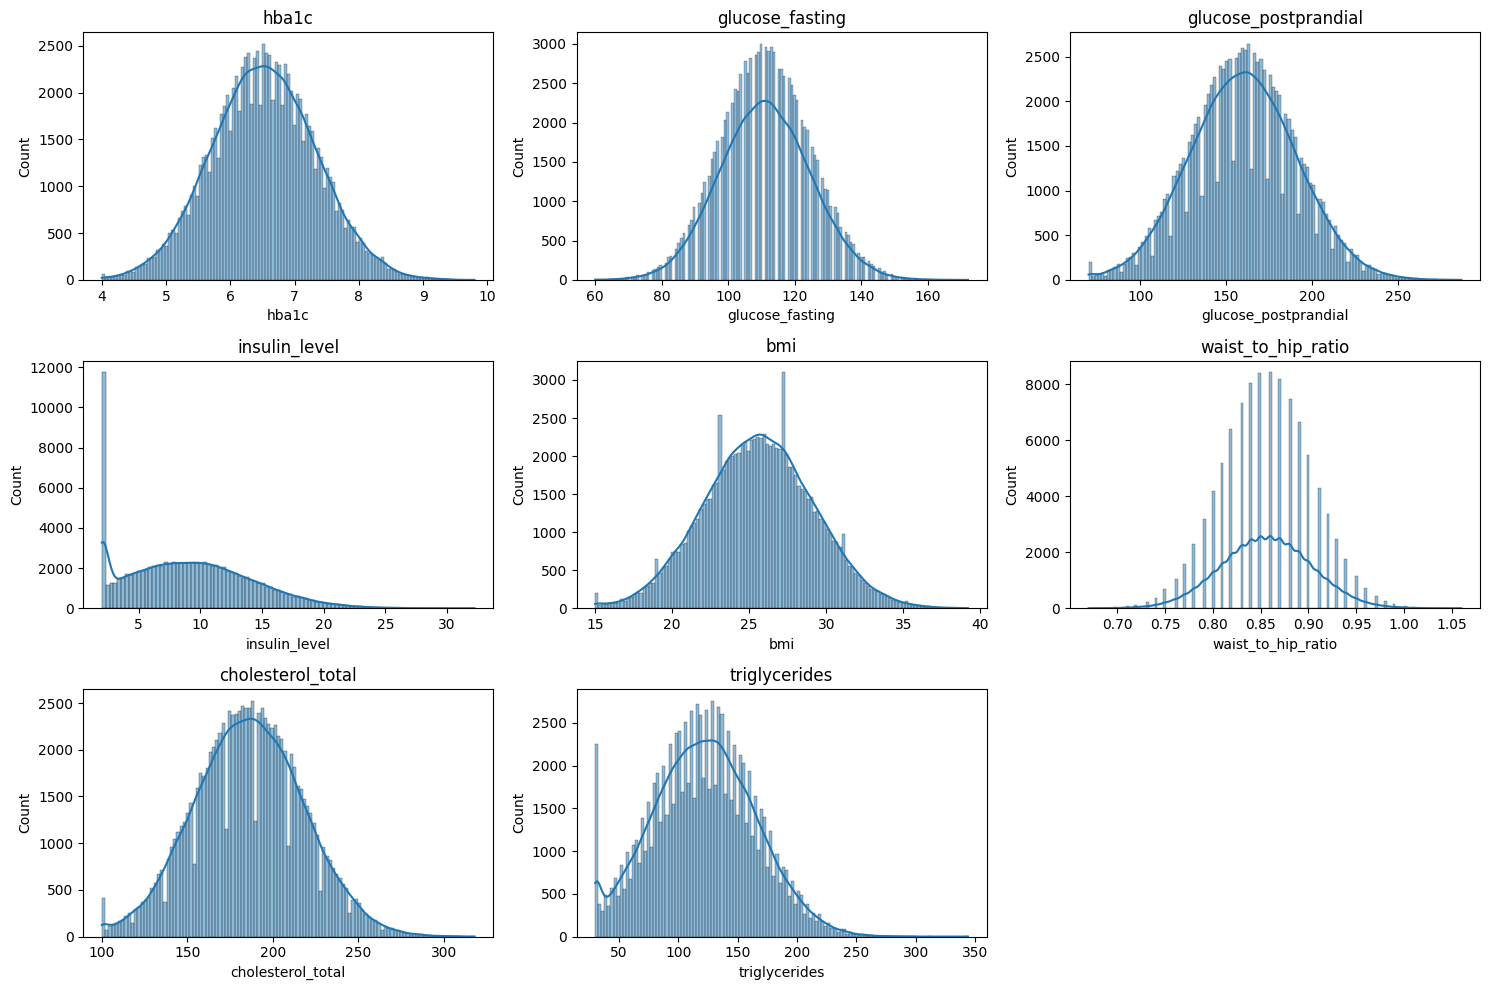

In [ ]:
important_cols=['hba1c','glucose_fasting','glucose_postprandial','insulin_level',
    'bmi',
    'waist_to_hip_ratio',
    'cholesterol_total',
    'triglycerides']
plt.figure(figsize=(15,10))

for i, col in enumerate(important_cols):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

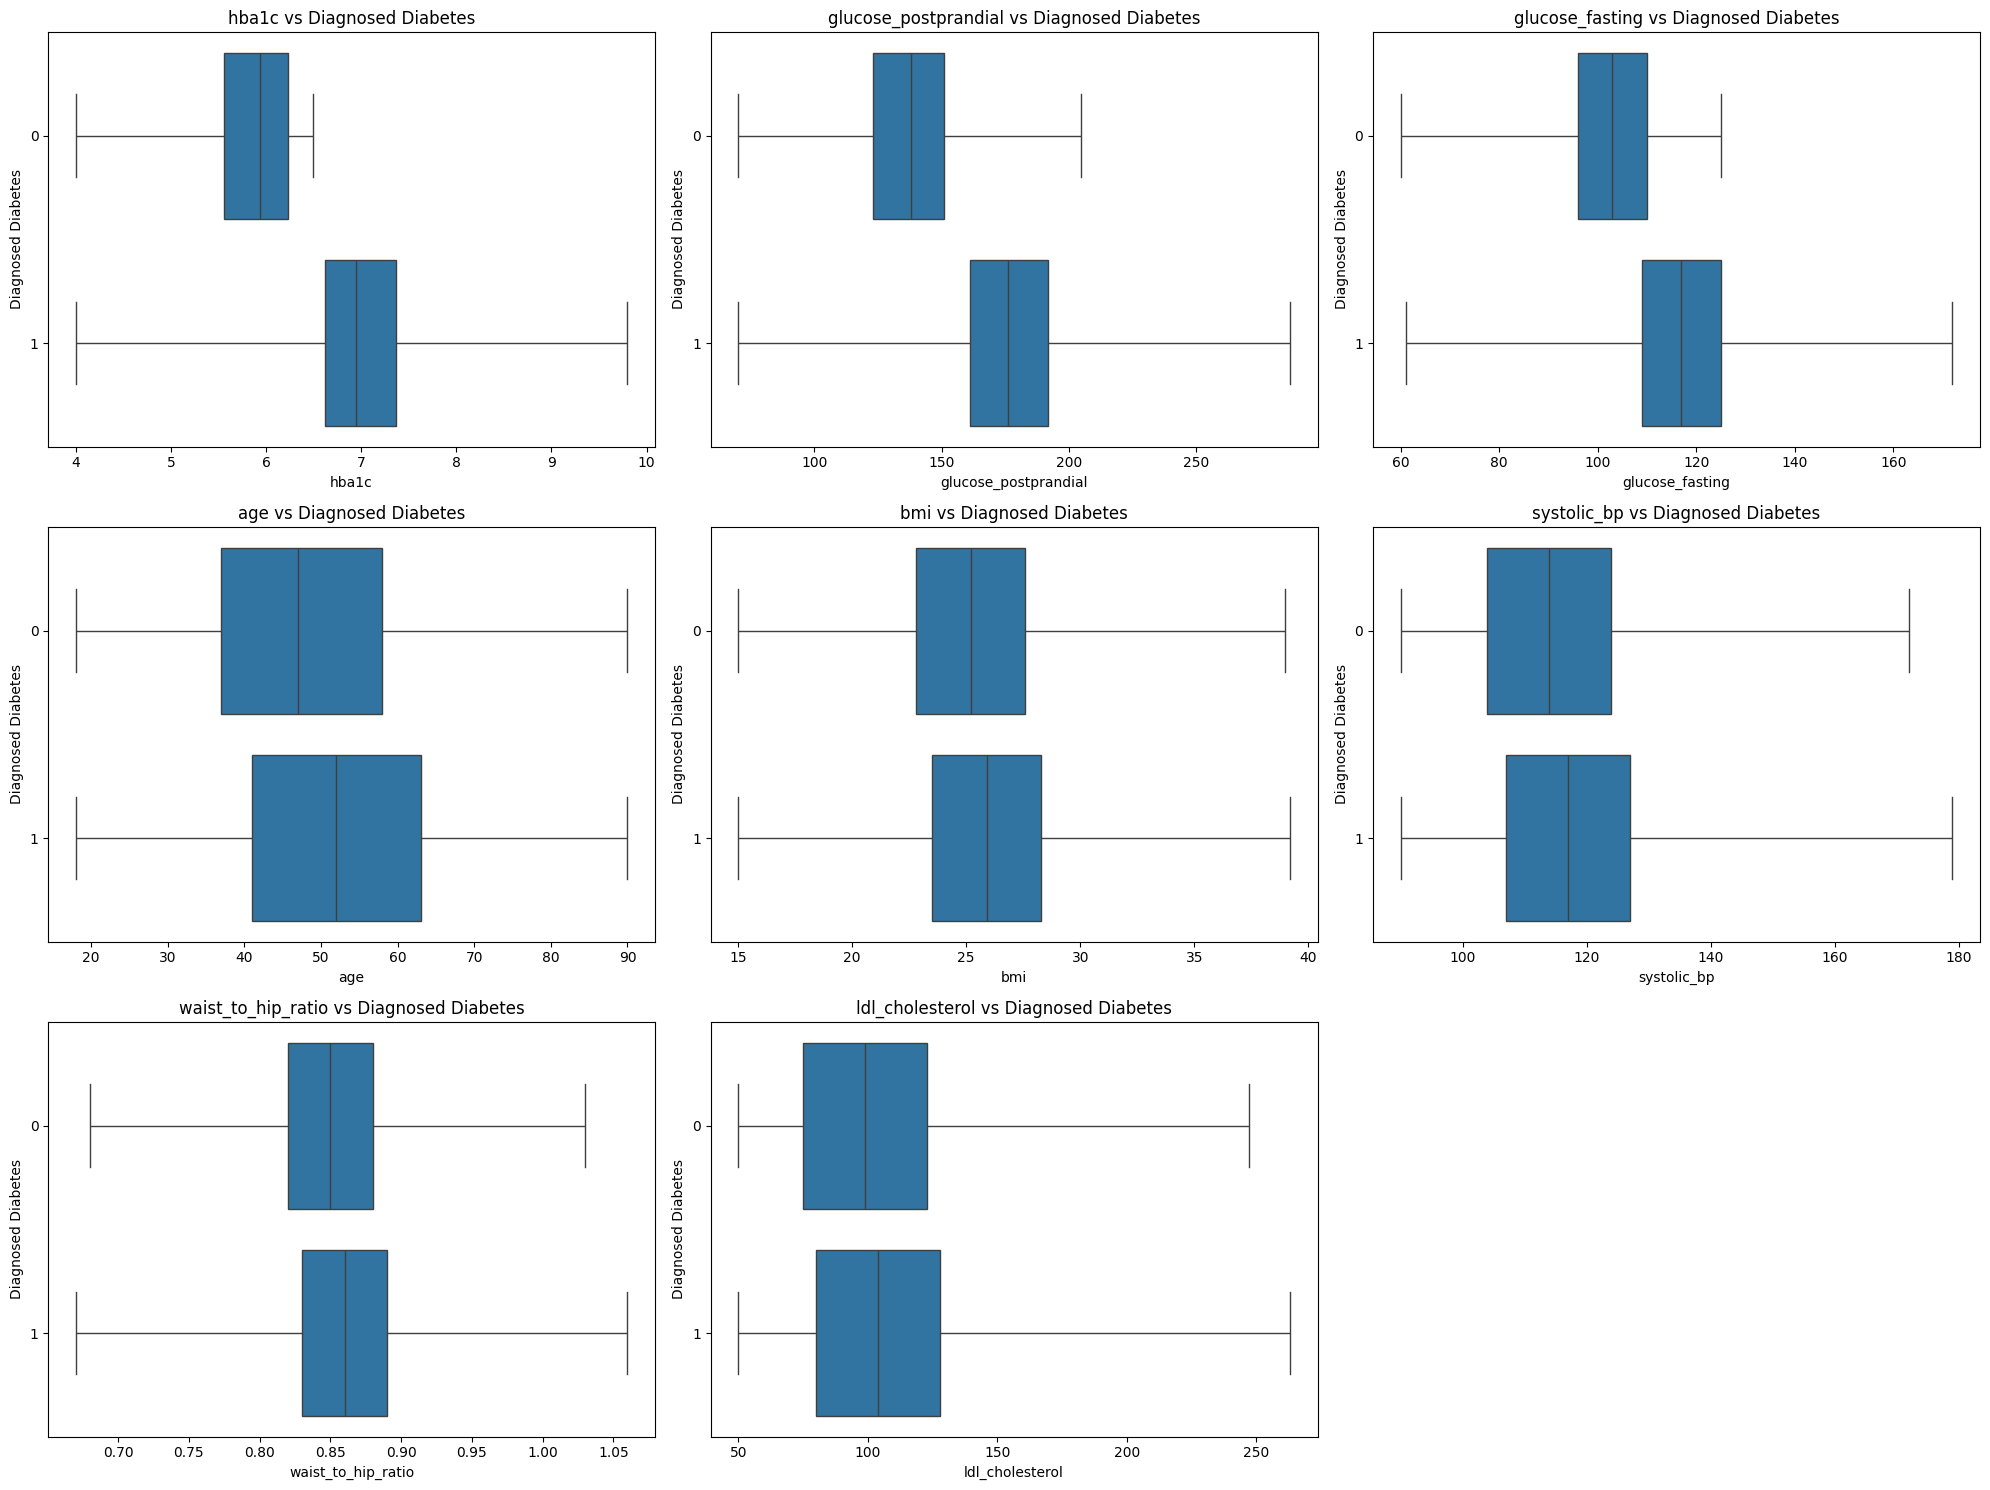

In [ ]:
important_cols = [
    'hba1c', 'glucose_postprandial', 'glucose_fasting', 'age', 'bmi',
    'systolic_bp', 'waist_to_hip_ratio', 'ldl_cholesterol']

plt.figure(figsize=(20, 15))

for i, col in enumerate(important_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y='diagnosed_diabetes', x=col, data=df, orient='h')
    plt.title(f'{col} vs Diagnosed Diabetes')
    plt.ylabel('Diagnosed Diabetes')

plt.tight_layout()
plt.show()

In [ ]:
cat_cols = df.select_dtypes(include=['object','int64']).columns
cat_cols = ['gender','family_history_diabetes','physical_activity_minutes_per_week','smoking_status','alcohol_consumption_per_week','diagnosed_diabetes']

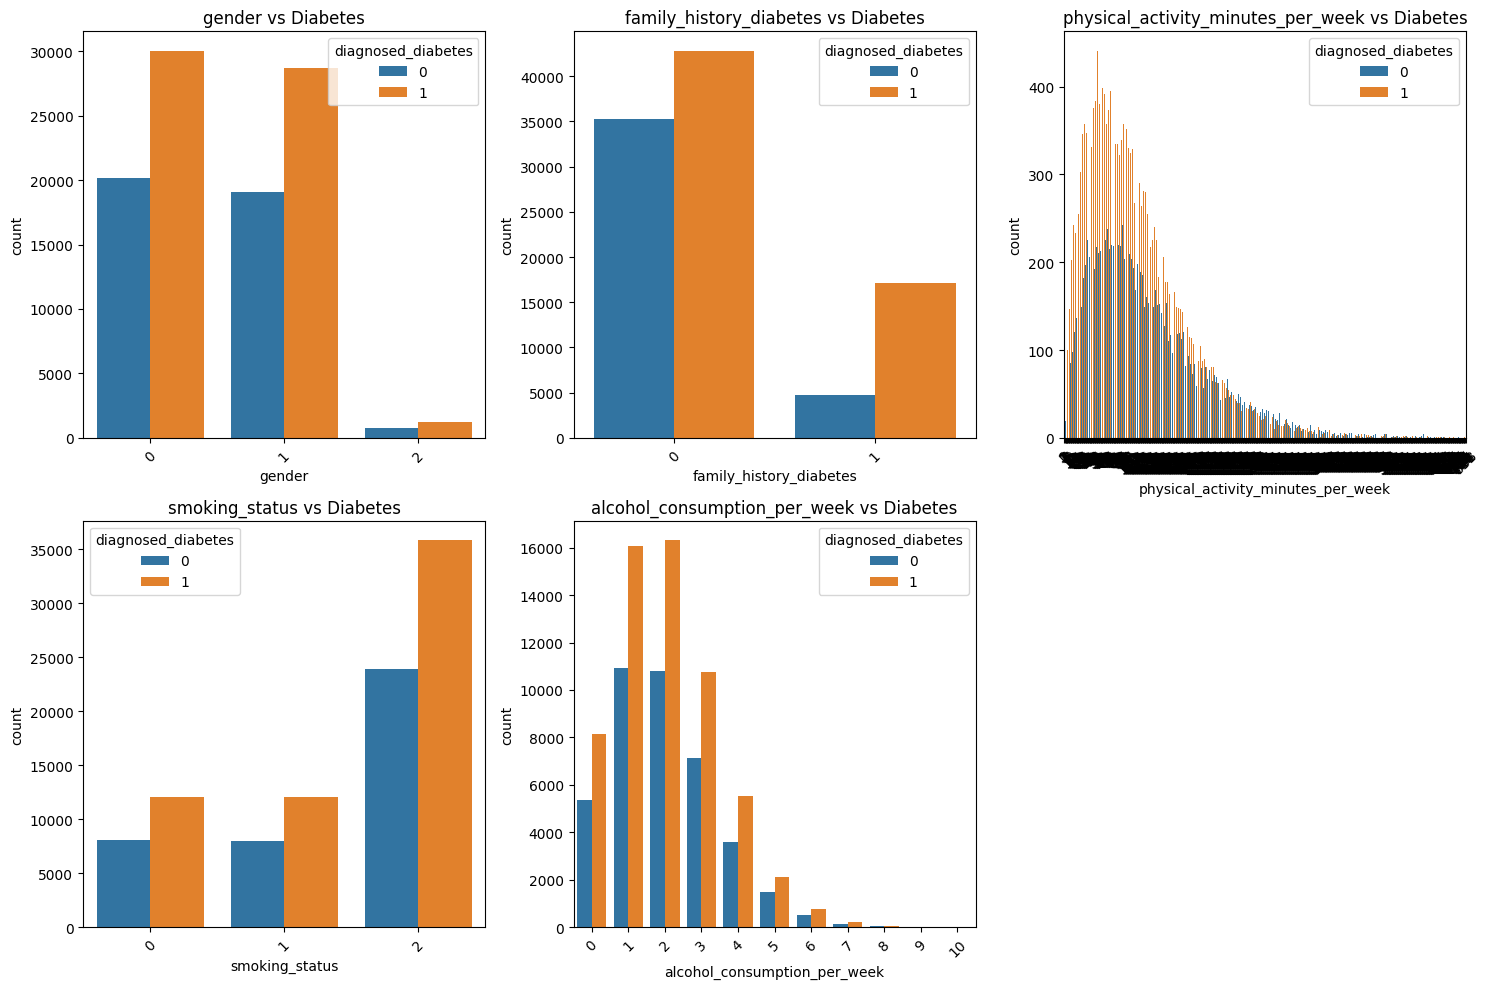

In [ ]:
plt.figure(figsize=(15,10))

for i, col in enumerate(cat_cols[:-1]):
    plt.subplot(2, 3, i+1)
    sns.countplot(x=df[col], hue=df['diagnosed_diabetes'])
    plt.title(f"{col} vs Diabetes")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Here I have showed the categorical columns vs target variable

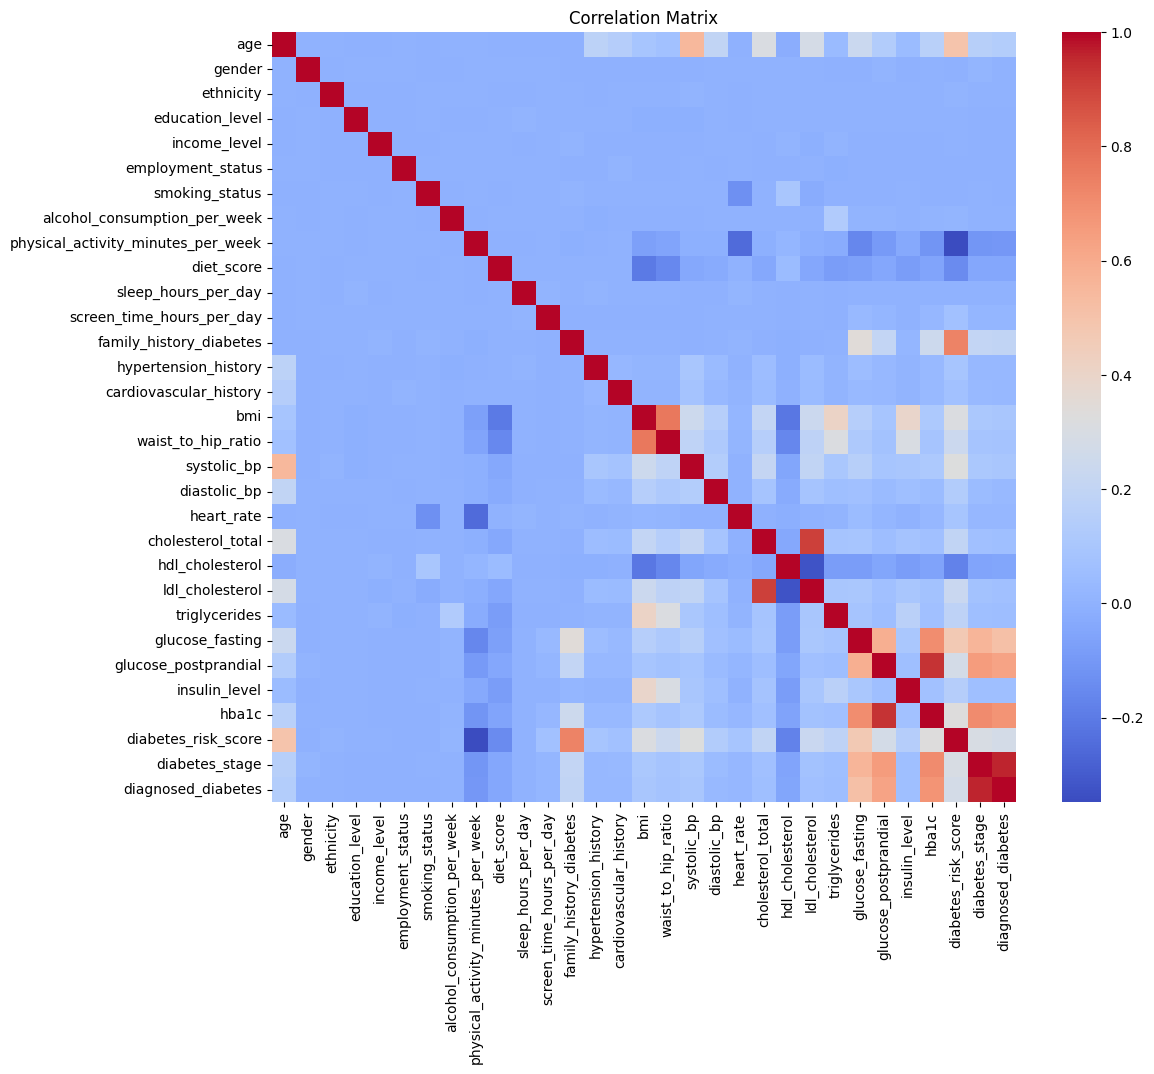

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Feature Selection

In [ ]:
df = df.drop(columns=['record_id', 'patient_id'], errors='ignore')

In [ ]:
corr = df.corr()['diagnosed_diabetes'].sort_values(ascending=False)
print(corr)

diagnosed_diabetes                    1.000000
diabetes_stage                        0.961453
hba1c                                 0.679397
glucose_postprandial                  0.629832
glucose_fasting                       0.510919
diabetes_risk_score                   0.277300
family_history_diabetes               0.197926
age                                   0.137713
bmi                                   0.097057
systolic_bp                           0.095481
waist_to_hip_ratio                    0.078918
ldl_cholesterol                       0.067475
cholesterol_total                     0.058173
insulin_level                         0.057715
triglycerides                         0.056230
diastolic_bp                          0.035619
cardiovascular_history                0.029793
hypertension_history                  0.027524
heart_rate                            0.022785
screen_time_hours_per_day             0.018127
gender                                0.004581
ethnicity    

In [ ]:
df = df.drop(columns=['diabetes_stage','diabetes_risk_score'], errors='ignore')

Initially, perfect accuracy was observed due to data leakage from target-related features. After removing these features, the model performance became realistic.

**Prepare data for modeling**

# Data spliting

In [ ]:
X = df.drop('diagnosed_diabetes', axis=1)
y = df['diagnosed_diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

print("\nTarget Distribution (Train):")
print(y_train.value_counts())

print("\nTarget Distribution (Test):")
print(y_test.value_counts())

Training Data Shape: (80000, 28)
Testing Data Shape: (20000, 28)

Target Distribution (Train):
diagnosed_diabetes
1    47998
0    32002
Name: count, dtype: int64

Target Distribution (Test):
diagnosed_diabetes
1    12000
0     8000
Name: count, dtype: int64


**Scaling (Standariztion)**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SMOTE

In [ ]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [ ]:
print("\nAfter SMOTE:")

print("Training Data Shape:", X_train_sm.shape)

print("\nBalanced Target Distribution:")
print(pd.Series(y_train_sm).value_counts())


After SMOTE:
Training Data Shape: (95996, 28)

Balanced Target Distribution:
diagnosed_diabetes
1    47998
0    47998
Name: count, dtype: int64


# Model Building



1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. AdaBoost
6. KNN
7. Naive Bayes

In [ ]:
results = pd.DataFrame(columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"])

# Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_sm, y_train_sm)

y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

# Evaluation

Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      8000
           1       0.93      0.88      0.90     12000

    accuracy                           0.89     20000
   macro avg       0.88      0.89      0.88     20000
weighted avg       0.89      0.89      0.89     20000



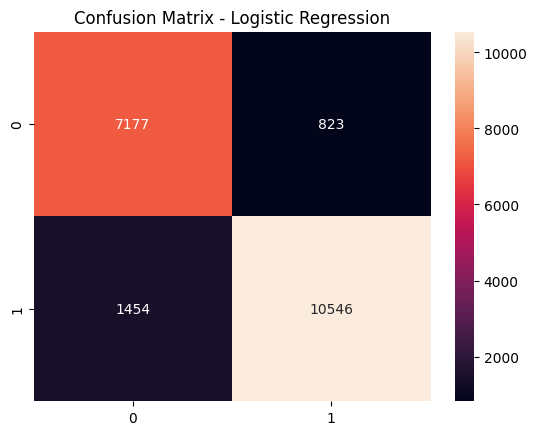

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("Logistic Regression")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

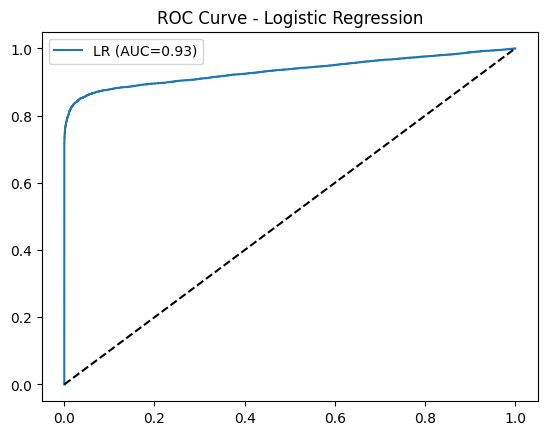

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"LR (AUC={roc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [ ]:
results.loc[len(results)] = ["Logistic Regression", acc, prec, rec, f1, roc]
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.88615,0.92761,0.878833,0.902563,0.933913


# Decision Tree


=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      8000
           1       0.88      0.89      0.89     12000

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000



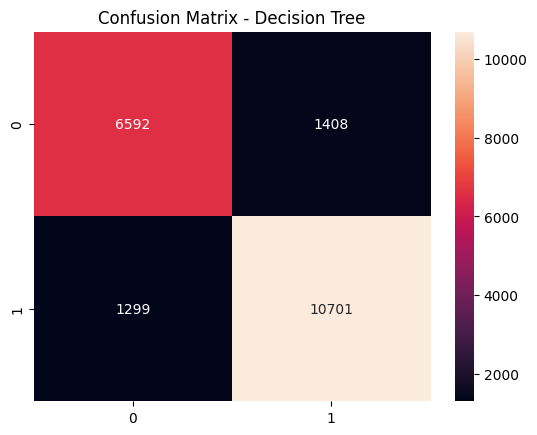

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_sm, y_train_sm)

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("\n=== Decision Tree ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

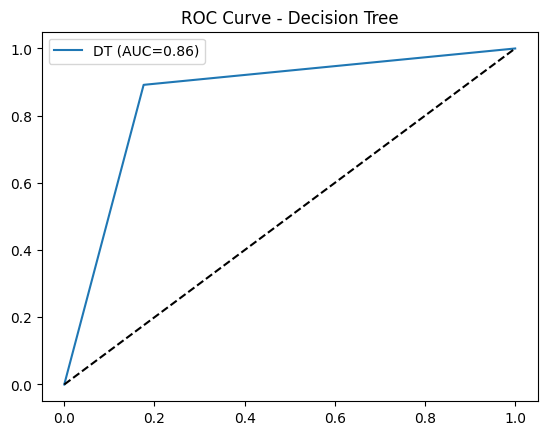

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"DT (AUC={roc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve - Decision Tree")
plt.show()

In [ ]:
results.loc[len(results)] = ["Decision Tree", acc, prec, rec, f1, roc]
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.88615,0.927610,0.878833,0.902563,0.933913
1,Decision Tree,0.86465,0.883723,0.891750,0.887718,0.857875


# Random forest


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



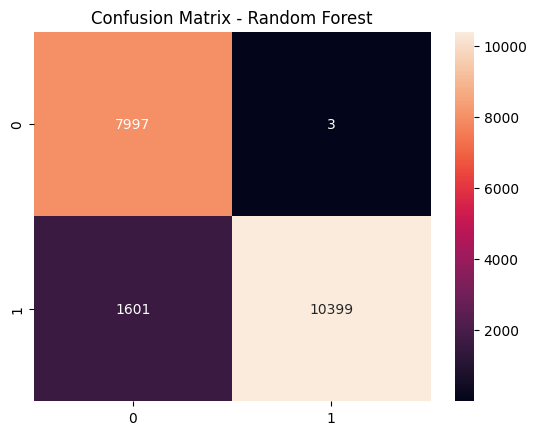

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_sm, y_train_sm)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

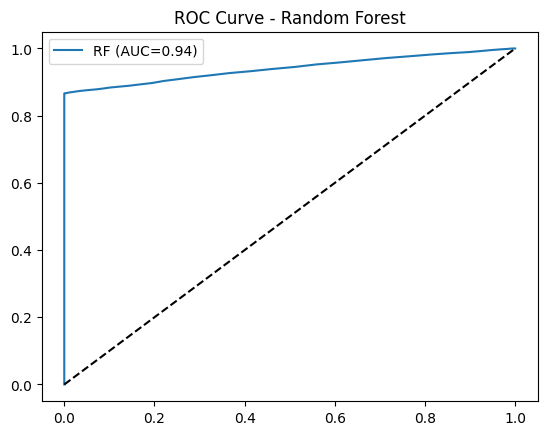

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"RF (AUC={roc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve - Random Forest")
plt.show()


In [ ]:
results.loc[len(results)] = ["Random Forest", acc, prec, rec, f1, roc]
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.88615,0.927610,0.878833,0.902563,0.933913
1,Decision Tree,0.86465,0.883723,0.891750,0.887718,0.857875
2,Random Forest,0.91980,0.999712,0.866583,0.928399,0.940550


# Gradient Boosting


=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



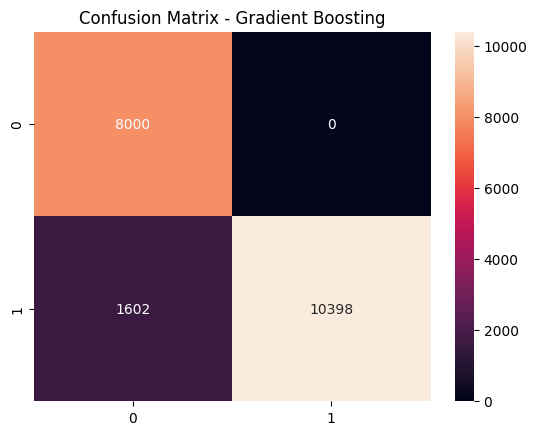

In [ ]:
gb = GradientBoostingClassifier()
gb.fit(X_train_sm, y_train_sm)

y_pred = gb.predict(X_test)
y_prob = gb.predict_proba(X_test)[:,1]


acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("\n=== Gradient Boosting ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

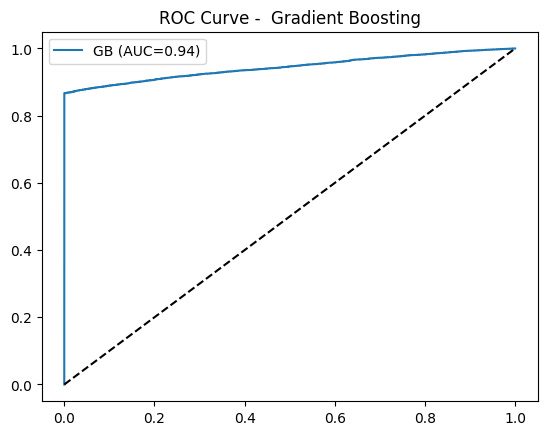

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"GB (AUC={roc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve -  Gradient Boosting")
plt.show()

In [ ]:
results.loc[len(results)] = ["Gradient Boosting", acc, prec, rec, f1, roc]
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.88615,0.927610,0.878833,0.902563,0.933913
1,Decision Tree,0.86465,0.883723,0.891750,0.887718,0.857875
2,Random Forest,0.91980,0.999712,0.866583,0.928399,0.940550
3,Gradient Boosting,0.91990,1.000000,0.866500,0.928476,0.944307


# AdaBoost


=== AdaBoost ===
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



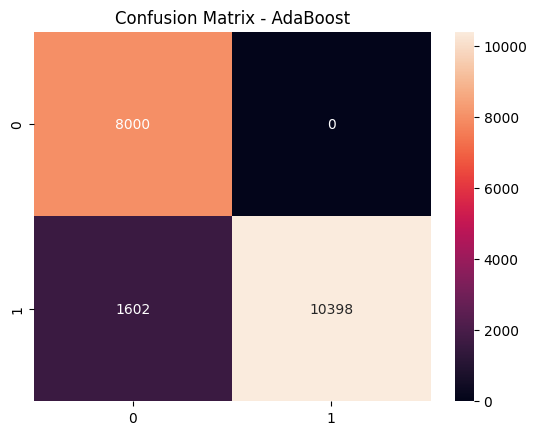

In [ ]:
ab = AdaBoostClassifier()
ab.fit(X_train_sm, y_train_sm)

y_pred = ab.predict(X_test)
y_prob = ab.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("\n=== AdaBoost ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - AdaBoost")
plt.show()

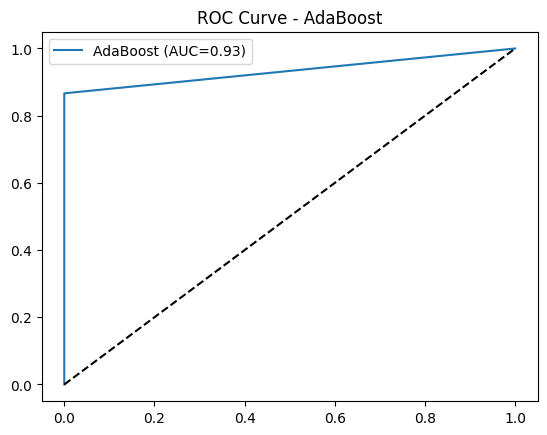

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AdaBoost (AUC={roc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve - AdaBoost")
plt.show()

In [ ]:
results.loc[len(results)] = ["AdaBoost", acc, prec, rec, f1, roc]
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.88615,0.927610,0.878833,0.902563,0.933913
1,Decision Tree,0.86465,0.883723,0.891750,0.887718,0.857875
2,Random Forest,0.91980,0.999712,0.866583,0.928399,0.940550
3,Gradient Boosting,0.91990,1.000000,0.866500,0.928476,0.944307
4,AdaBoost,0.91990,1.000000,0.866500,0.928476,0.933250


# KNN


=== KNN ===
              precision    recall  f1-score   support

           0       0.69      0.87      0.77      8000
           1       0.90      0.73      0.81     12000

    accuracy                           0.79     20000
   macro avg       0.79      0.80      0.79     20000
weighted avg       0.81      0.79      0.79     20000



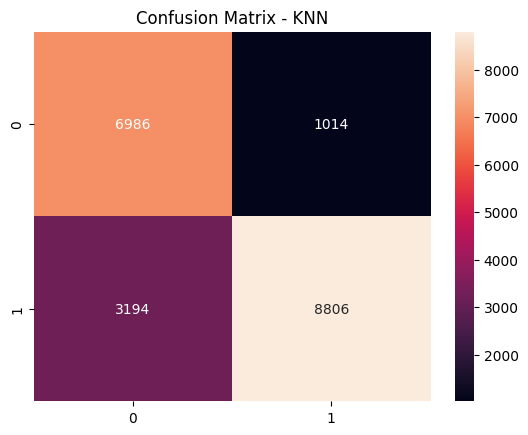

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sm, y_train_sm)

y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("\n=== KNN ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - KNN")
plt.show()

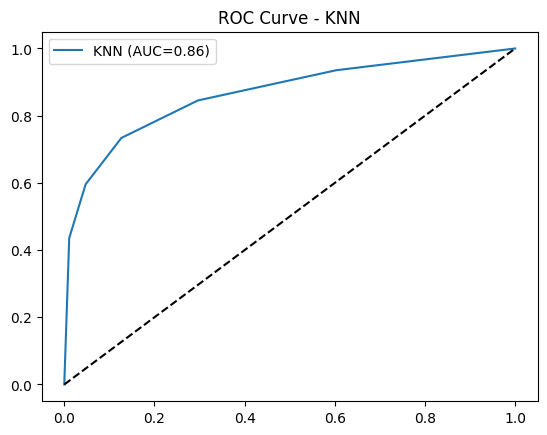

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"KNN (AUC={roc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve - KNN")
plt.show()


In [ ]:
results.loc[len(results)] = ["KNN", acc, prec, rec, f1, roc]
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.88615,0.927610,0.878833,0.902563,0.933913
1,Decision Tree,0.86465,0.883723,0.891750,0.887718,0.857875
2,Random Forest,0.91980,0.999712,0.866583,0.928399,0.940550
3,Gradient Boosting,0.91990,1.000000,0.866500,0.928476,0.944307
4,AdaBoost,0.91990,1.000000,0.866500,0.928476,0.933250
5,KNN,0.78960,0.896741,0.733833,0.807149,0.864986


# Naive Bayes


=== Naive Bayes ===
              precision    recall  f1-score   support

           0       0.79      0.87      0.83      8000
           1       0.91      0.84      0.88     12000

    accuracy                           0.86     20000
   macro avg       0.85      0.86      0.85     20000
weighted avg       0.86      0.86      0.86     20000



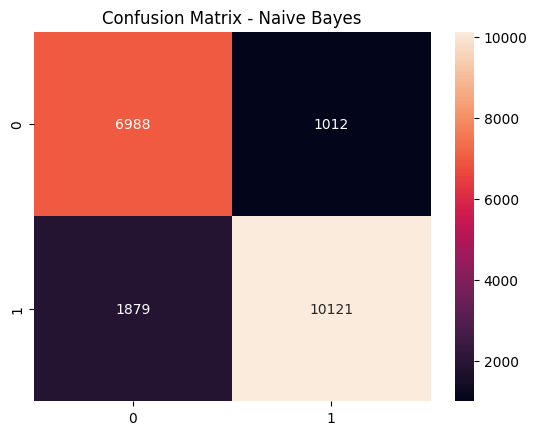

In [ ]:
nb = GaussianNB()
nb.fit(X_train_sm, y_train_sm)

y_pred = nb.predict(X_test)
y_prob = nb.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("\n=== Naive Bayes ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

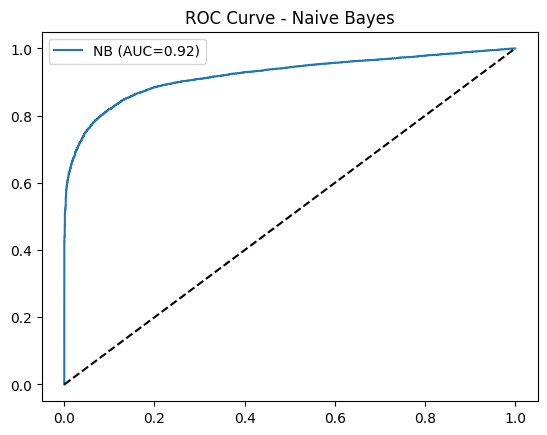

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"NB (AUC={roc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve - Naive Bayes")
plt.show()

In [ ]:
results.loc[len(results)] = ["Naive Bayes", acc, prec, rec, f1, roc]
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.88615,0.927610,0.878833,0.902563,0.933913
1,Decision Tree,0.86465,0.883723,0.891750,0.887718,0.857875
2,Random Forest,0.91980,0.999712,0.866583,0.928399,0.940550
3,Gradient Boosting,0.91990,1.000000,0.866500,0.928476,0.944307
4,AdaBoost,0.91990,1.000000,0.866500,0.928476,0.933250
5,KNN,0.78960,0.896741,0.733833,0.807149,0.864986
6,Naive Bayes,0.85545,0.909099,0.843417,0.875027,0.920853



# Random Forest Optimization (Using RandomizedSearch)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found for Random Forest:  {'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 10, 'bootstrap': True}

=== Optimized Random Forest ===
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



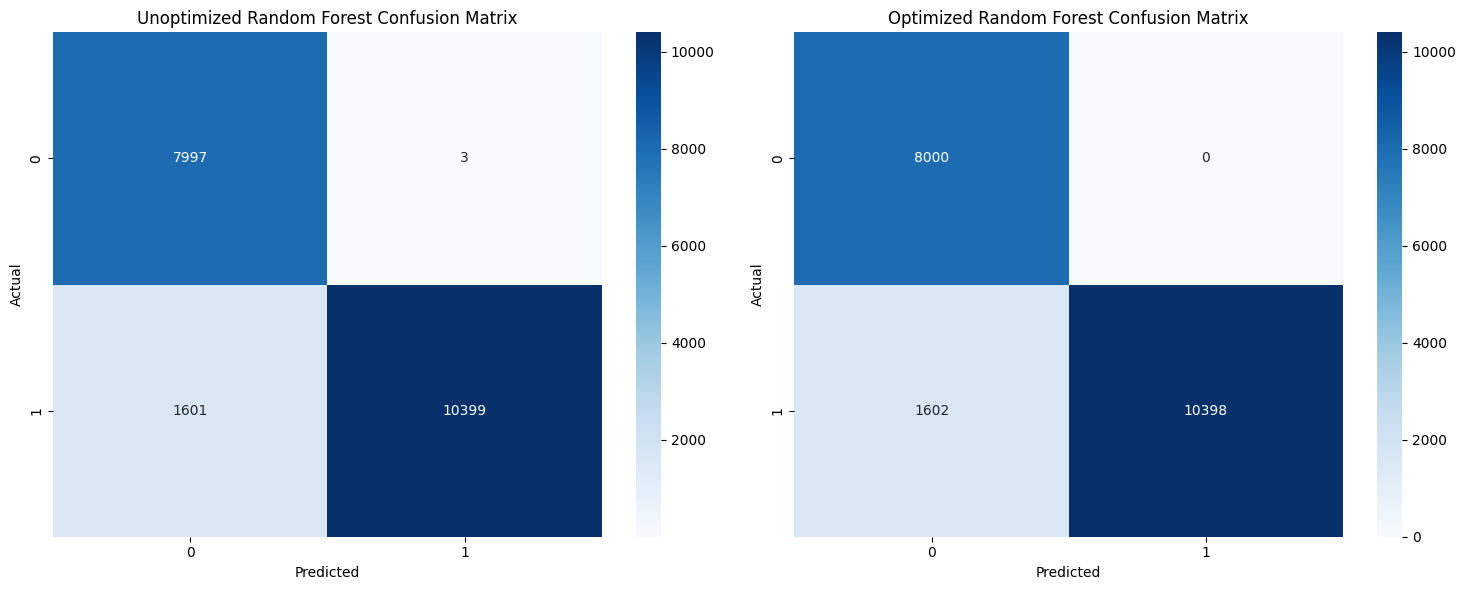

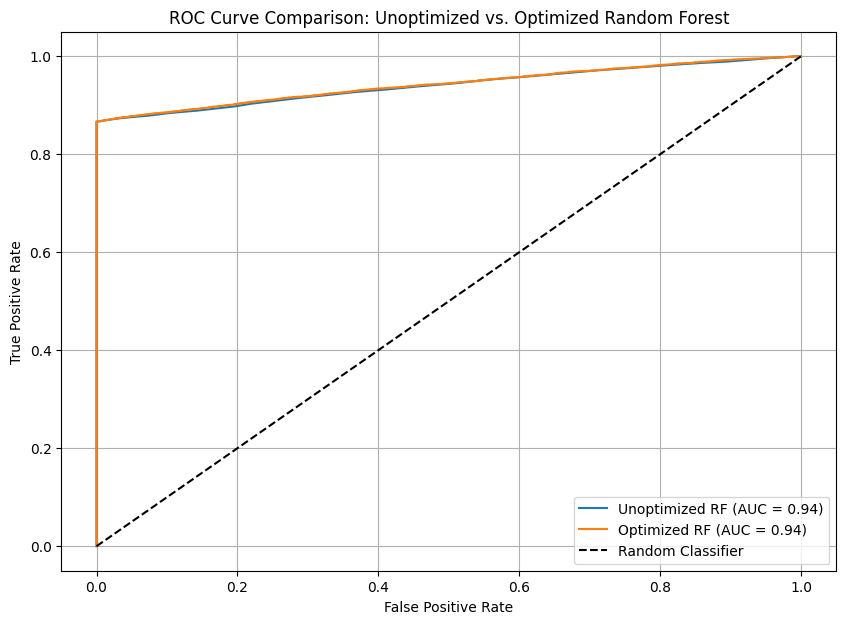


=== FINAL MODEL COMPARISON (including Optimized RF) ===
                     Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
3        Gradient Boosting   0.91990   1.000000  0.866500  0.928476  0.944307
4                 AdaBoost   0.91990   1.000000  0.866500  0.928476  0.933250
7  Random Forest Optimized   0.91990   1.000000  0.866500  0.928476  0.942355
2            Random Forest   0.91980   0.999712  0.866583  0.928399  0.940550
0      Logistic Regression   0.88615   0.927610  0.878833  0.902563  0.933913
1            Decision Tree   0.86465   0.883723  0.891750  0.887718  0.857875
6              Naive Bayes   0.85545   0.909099  0.843417  0.875027  0.920853
5                      KNN   0.78960   0.896741  0.733833  0.807149  0.864986


In [ ]:
param_dist_rf = {'n_estimators': [100, 150, 200, 250],'max_depth': [10, 20, 30, None],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4],'bootstrap': [True, False]}

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=10,  # Number of parameter settings that are sampled
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1')

random_search_rf.fit(X_train_sm, y_train_sm)

print("Best parameters found for Random Forest: ", random_search_rf.best_params_)

rf_opt = random_search_rf.best_estimator_

y_pred_opt_rf = rf_opt.predict(X_test)
y_prob_opt_rf = rf_opt.predict_proba(X_test)[:,1]


acc_opt_rf = accuracy_score(y_test, y_pred_opt_rf)
prec_opt_rf = precision_score(y_test, y_pred_opt_rf)
rec_opt_rf = recall_score(y_test, y_pred_opt_rf)
f1_opt_rf = f1_score(y_test, y_pred_opt_rf)
roc_opt_rf = roc_auc_score(y_test, y_prob_opt_rf)

print("\n=== Optimized Random Forest ===")
print(classification_report(y_test, y_pred_opt_rf))


cm_unoptimized_rf = confusion_matrix(y_test, rf.predict(X_test))
fpr_unoptimized_rf, tpr_unoptimized_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
roc_unoptimized_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])


fig, axes = plt.subplots(1, 2, figsize=(15, 6))


sns.heatmap(cm_unoptimized_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Unoptimized Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')


cm_optimized_rf = confusion_matrix(y_test, y_pred_opt_rf)
sns.heatmap(cm_optimized_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Optimized Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


fpr_opt_rf, tpr_opt_rf, _ = roc_curve(y_test, y_prob_opt_rf)


plt.figure(figsize=(10, 7))
plt.plot(fpr_unoptimized_rf, tpr_unoptimized_rf, label=f'Unoptimized RF (AUC = {roc_unoptimized_rf:.2f})')
plt.plot(fpr_opt_rf, tpr_opt_rf, label=f'Optimized RF (AUC = {roc_opt_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Unoptimized vs. Optimized Random Forest')
plt.legend()
plt.grid(True)
plt.show()

results.loc[len(results)] = ["Random Forest Optimized", acc_opt_rf, prec_opt_rf, rec_opt_rf, f1_opt_rf, roc_opt_rf]
results = results.sort_values(by="F1 Score", ascending=False)

print("\n=== FINAL MODEL COMPARISON (including Optimized RF) ===")
print(results)

# Gradient Boosting Optimization (Using RandomizedSearch)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found:  {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.01}

=== Optimized Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.83      1.00      0.91      8000
           1       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



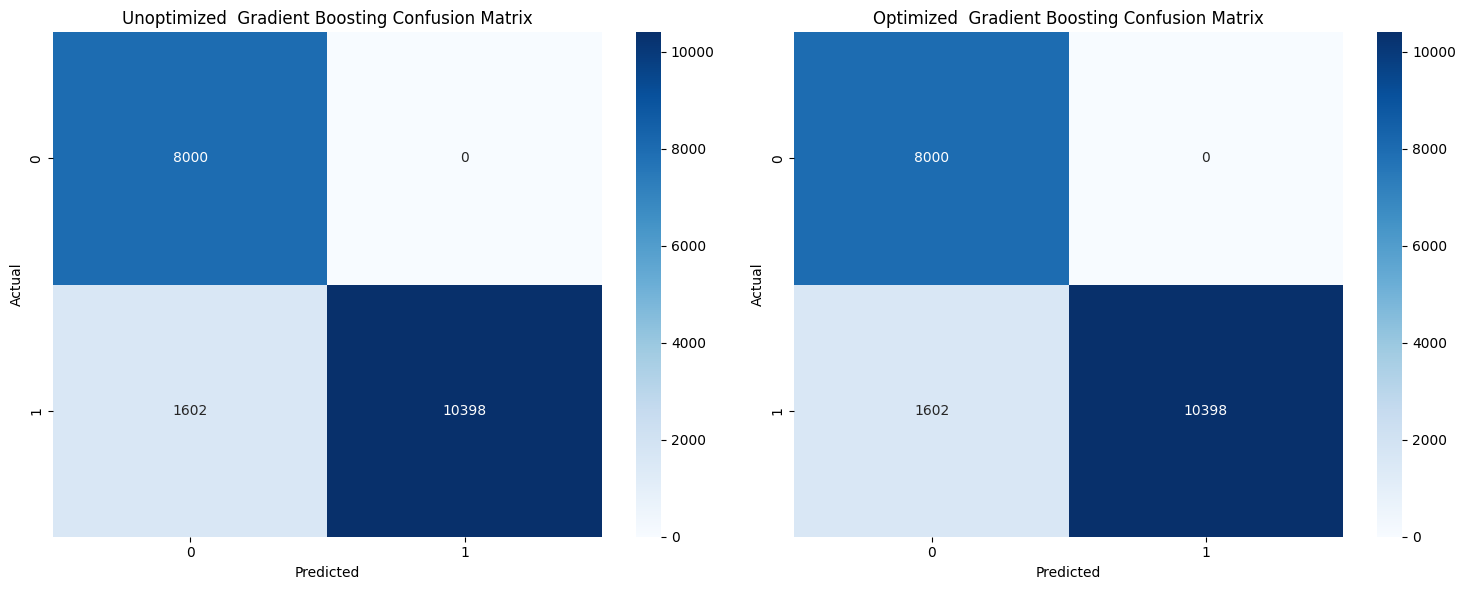

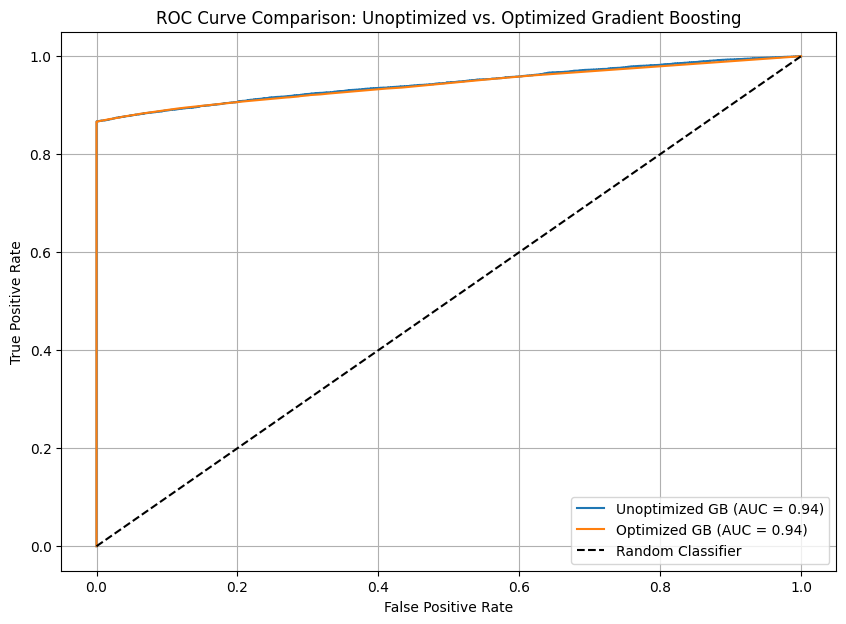


=== FINAL MODEL COMPARISON (including Optimized GB) ===
                         Model  Accuracy  Precision    Recall  F1 Score  \
3            Gradient Boosting   0.91990   1.000000  0.866500  0.928476   
4                     AdaBoost   0.91990   1.000000  0.866500  0.928476   
7      Random Forest Optimized   0.91990   1.000000  0.866500  0.928476   
8  Gradient Boosting Optimized   0.91990   1.000000  0.866500  0.928476   
2                Random Forest   0.91980   0.999712  0.866583  0.928399   
0          Logistic Regression   0.88615   0.927610  0.878833  0.902563   
1                Decision Tree   0.86465   0.883723  0.891750  0.887718   
6                  Naive Bayes   0.85545   0.909099  0.843417  0.875027   
5                          KNN   0.78960   0.896741  0.733833  0.807149   

    ROC-AUC  
3  0.944307  
4  0.933250  
7  0.942355  
8  0.942539  
2  0.940550  
0  0.933913  
1  0.857875  
6  0.920853  
5  0.864986  


In [ ]:
param_dist = {'n_estimators': [100, 150, 200, 250],'learning_rate': [0.01, 0.05, 0.1, 0.2],'max_depth': [3, 4, 5, 6],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}

random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1')

random_search.fit(X_train_sm, y_train_sm)

print("Best parameters found: ", random_search.best_params_)

gb_opt = random_search.best_estimator_

y_pred_opt = gb_opt.predict(X_test)
y_prob_opt = gb_opt.predict_proba(X_test)[:,1]


acc_opt = accuracy_score(y_test, y_pred_opt)
prec_opt = precision_score(y_test, y_pred_opt)
rec_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)
roc_opt = roc_auc_score(y_test, y_prob_opt)

print("\n=== Optimized Gradient Boosting ===")
print(classification_report(y_test, y_pred_opt))


cm_unoptimized = confusion_matrix(y_test, gb.predict(X_test))
fpr_unoptimized, tpr_unoptimized, _ = roc_curve(y_test, gb.predict_proba(X_test)[:,1])
roc_unoptimized = roc_auc_score(y_test, gb.predict_proba(X_test)[:,1])


fig, axes = plt.subplots(1, 2, figsize=(15, 6))


sns.heatmap(cm_unoptimized, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Unoptimized  Gradient Boosting Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')


cm_optimized = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Optimized  Gradient Boosting Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


fpr_opt, tpr_opt, _ = roc_curve(y_test, y_prob_opt)


plt.figure(figsize=(10, 7))
plt.plot(fpr_unoptimized, tpr_unoptimized, label=f'Unoptimized GB (AUC = {roc_unoptimized:.2f})')
plt.plot(fpr_opt, tpr_opt, label=f'Optimized GB (AUC = {roc_opt:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Unoptimized vs. Optimized Gradient Boosting')
plt.legend()
plt.grid(True)
plt.show()

results.loc[len(results)] = ["Gradient Boosting Optimized", acc_opt, prec_opt, rec_opt, f1_opt, roc_opt]
results = results.sort_values(by="F1 Score", ascending=False)

print("\n=== FINAL MODEL COMPARISON (including Optimized GB) ===")
print(results)

In [ ]:
results = results.sort_values(by="F1 Score", ascending=False)

print("\n=== FINAL MODEL COMPARISON ===")
print(results)


=== FINAL MODEL COMPARISON ===
                         Model  Accuracy  Precision    Recall  F1 Score  \
3            Gradient Boosting   0.91990   1.000000  0.866500  0.928476   
4                     AdaBoost   0.91990   1.000000  0.866500  0.928476   
7      Random Forest Optimized   0.91990   1.000000  0.866500  0.928476   
8  Gradient Boosting Optimized   0.91990   1.000000  0.866500  0.928476   
2                Random Forest   0.91980   0.999712  0.866583  0.928399   
0          Logistic Regression   0.88615   0.927610  0.878833  0.902563   
1                Decision Tree   0.86465   0.883723  0.891750  0.887718   
6                  Naive Bayes   0.85545   0.909099  0.843417  0.875027   
5                          KNN   0.78960   0.896741  0.733833  0.807149   

    ROC-AUC  
3  0.944307  
4  0.933250  
7  0.942355  
8  0.942539  
2  0.940550  
0  0.933913  
1  0.857875  
6  0.920853  
5  0.864986  


**Model Performance**

When comparing the performance of various classification models, various classification metrics like Accuracy, Precision, Recall, and F1 Score were evaluated. The goal was to identify the most effective model for predicting diabetes.

Gradient Boosting, AdaBoost, Random Forest, Optimized ones consistently achieved the highest F1 Scores, all around 0.928, this means a balance between Precision and Recall. Notably, many of these models showed a Precision: 1.00 this means every patient when predicted that they have diabetes it means they actually had it. These modles's  Recall was approximately 0.86-0.87, suggesting that about 86-87% of actual diabetic cases were correctly identified.

On the other hand, Logistic Regression showa best performence. its F1 score is 0.902563 with high precision of 0.927610 and good recall of 0.878833. Then decision tree gave lower performance where F1 score is 0.887718 , accuracy, precision and recall is 0.86465,   0.883723  0.891750 this means its performing reasonably. Moreover, Naive Bayes is standing in the middle. Lastly KNN performed really poor. Its accuracy is 0.78960, precision is 0.896741, recall is 0.733833 and F1 score is
0.807149. which shows it missed a significant part os actual diabetic cases.

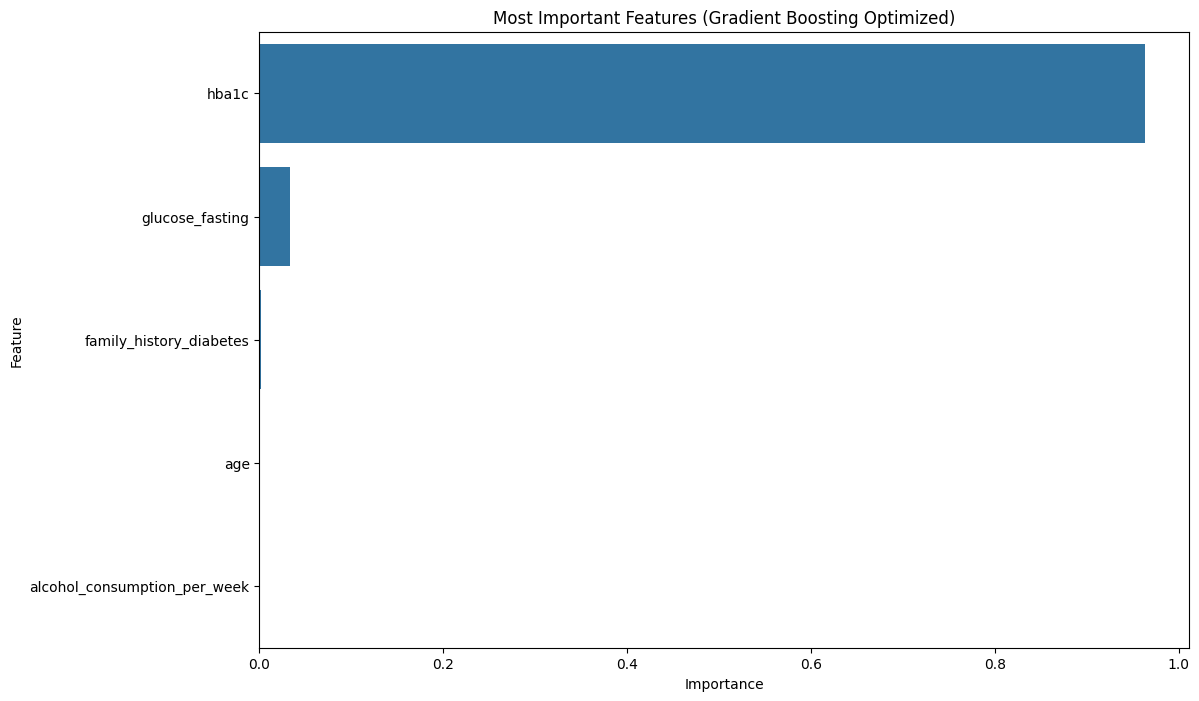

In [ ]:
feature_importances = gb_opt.feature_importances_
features = X.columns

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head())
plt.title('Most Important Features (Gradient Boosting Optimized)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

Based on the gradient boosting optimized model, hba1c is the most important feature and glucose fasting is the second important feature but it has very lower impact than hba1c on target variable (diagnosed diabetes)

# Business Insights and Recommendations

**Interpretation of Key Predictors and Their Impact**

Based on the Gradient Boosting Optimized model, here are the most important variables that impacting the target variable (diagnosed_diabetes):

**1.** **hba1c**: Its an indicator of long term blood sugar control and when its higher, its strognly associated with diabetes.

**2.** **glucose_fasting**: High fasting glucose is another primary indicator of diabetes.

These are the direct predictors of glucose metabolism. Which are directly impacting the target variable.



**Business Applications and Decision Support**

The outcomes of diabetes prediction model can significantly enhance business decisions in various essential areas, such as:

**1. Healthcare Organizations:** Hospital and clinics can Identify high risk patients and afterward they can do preventative programs, closer monitoring etc. They can provide lifestyle recommendations and tailor treatment plans according to individual risk profiles predicted by the model. Furthermore, it will lead to more effective patient management.

**2. Insurance Companies:**
By using the model insurance companies can evaluate applications and whether to provide  coverage becuase it will help to accurately assess an individual's diabetes risk. Moreover, if we focus on preventing the diabetes by using the model we can avoid those serious complications later, which saves a lot of money in the long run. The cost management would be easy.

**3. Public Health Care Organizations:** Most risk groups identified by the model as most vulnerable, Public health care organizations can develop and lunch highly targeted public health campaign for them.

**4. Employees Wellness Program:** Companies can design wellness programs for their employees to reduce the risk of diabetes. This can include activities like improving diet, encouraging physical activity, and regular health checkups.

This is how businesses can apply the model’s outcomes to improve decisions for betterment.  

**Limitations and Improvements**

**1. Limitations**
One of the limitations of this dataset is it doesn't contain world's population's data, which means we cant use the model generally for all people.
Furthermore, crucial factors such as genetic information or lifestyle habits (for example, specific dietary patterns, detailed exercise routines) were not included, which could offer deeper insights into diabetes risk.

Another point to consider is the use of SMOTE for handling class imbalance. While effective, SMOTE generates synthetic data points, which might introduce artificial patterns or noise, potentially altering the true underlying data distribution. Lastly, it's important to remember that this model provides a predictive risk assessment and should not replace professional medical diagnosis or clinical judgment.

**2. Recommendations for Improvement**

To enhance the model's accuracy and robustness, several improvements can be considered:

*   **Feature Enrichment:** Incorporate additional relevant features, such as genetics, detailed physical activity tracking, and psychological factors (such as stress levels, anxiety). This would provide a more vast view of an individual's health profile, Which will help
the model to run more accurately and it will also show accurte results.
*   **Advanced Modeling Techniques:** Explore more sophisticated machine learning algorithms like XGBoost, LightGBM, or even deep learning approaches.